___________________________________
# Bank Customer Churn Prediction

## Tools Used

- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-Learn

## Machine Learning Models

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- K-Means Clustering

## Project Objective

The objective of this project is to analyze bank customer data and build machine learning models to predict customer churn. The project aims to identify the key factors influencing customer attrition, compare multiple classification algorithms, and generate actionable business insights to improve customer retention strategies.
___________________________________

___________________________________
## Initial Observation

- Dataset contains 10,000 customer records.
- Target variable is Exited.
- Exited = 1 indicates customer churn.
- Exited = 0 indicates retained customer.
- Dataset contains customer demographic and banking information.
___________________________________

___________________________________
# SECTION 1 — Import Libraries
* Importing required Python libraries for data analysis, visualization, and machine learning.
___________________________________

In [1]:
# Data Handling

import numpy as np
import pandas as pd

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

___________________________________
# SECTION 2 — Data Loading and Initial Exploration
In this section, we'll load the dataset, provide an overview of its structure, and perform data quality checks to identify missing values and duplicate records.
___________________________________

___________________________________
## Load Dataset
* Loading the Bank Customer Churn dataset into a pandas DataFrame for analysis.
___________________________________

In [2]:
# Load Dataset

df = pd.read_csv("../Dataset/Bank Customer Churn Raw Data.csv")

___________________________________
## Dataset Overview
* Understanding dataset structure using shape, columns, data types, and statistical summary.
___________________________________

In [3]:
# Display Dataset

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Dataset Shape

df.shape

(10000, 14)

In [5]:
# Column Names

df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [6]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
# Statistical Summary

df.describe().round()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,5000.0,15690941.0,651.0,39.0,5.0,76486.0,2.0,1.0,1.0,100090.0,0.0
std,2887.0,71936.0,97.0,10.0,3.0,62397.0,1.0,0.0,0.0,57510.0,0.0
min,1.0,15565701.0,350.0,18.0,0.0,0.0,1.0,0.0,0.0,12.0,0.0
25%,2501.0,15628528.0,584.0,32.0,3.0,0.0,1.0,0.0,0.0,51002.0,0.0
50%,5000.0,15690738.0,652.0,37.0,5.0,97199.0,1.0,1.0,1.0,100194.0,0.0
75%,7500.0,15753234.0,718.0,44.0,7.0,127644.0,2.0,1.0,1.0,149388.0,0.0
max,10000.0,15815690.0,850.0,92.0,10.0,250898.0,4.0,1.0,1.0,199992.0,1.0


___________________________________
## Data Quality Check
* Checking missing values and duplicate records in the dataset.
___________________________________

In [8]:
# Check Missing Values

df.isnull().head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
# Check Duplicate Records

df.duplicated().sum()

np.int64(0)

___________________________________
# SECTION 3 — Exploratory Data Analysis (EDA)
* Performing exploratory data analysis to identify customer behavior patterns using visualizations to understand churn distribution and key factors.
___________________________________

___________________________________
## Unique Values Analysis
* #### Unique Values in Categorical Columns
    * Checking unique categories present in categorical columns.
___________________________________

In [11]:
df["Geography"].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [12]:
df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

___________________________________
## Now Visualization the Data
* ### 1. Target Variable Analysis
❓ Question:- What is the distribution of churned vs retained customers?
___________________________________

In [13]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

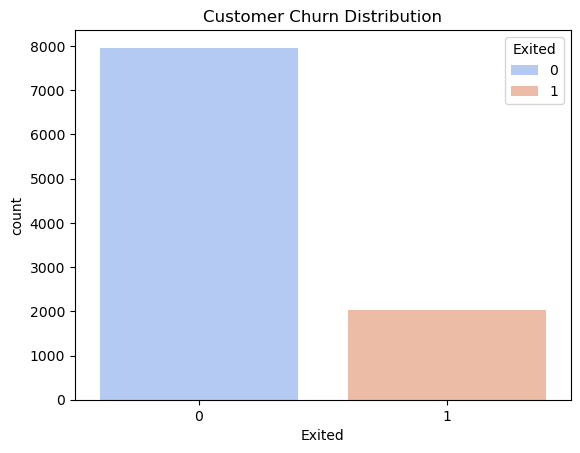

In [14]:
sns.countplot(x='Exited', data=df, hue= 'Exited', palette='coolwarm')
plt.title("Customer Churn Distribution")
plt.show()

___________________________________
### Insight

* 👉 Most customers are retained (0) compared to churned customers (1).
* 👉 This shows class imbalance in the dataset.
___________________________________

___________________________________
## 2. Geography Analysis
❓ Question: Which country has the highest number of customers?
___________________________________

In [15]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

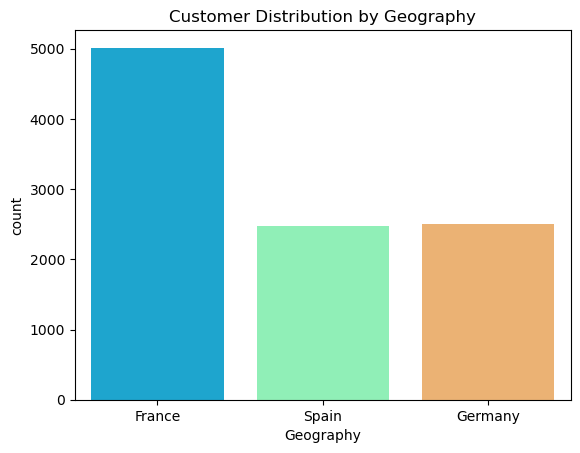

In [16]:
sns.countplot(x= 'Geography', data= df, hue= 'Geography', palette='rainbow')
plt.title('Customer Distribution by Geography')
plt.show()

___________________________________
### Insight
* 👉 Majority of customers belong to France.
* 👉 Germany and Spain have comparatively fewer customers.
___________________________________

___________________________________
## 3. Geography vs Churn
❓ Question: Does geography impact customer churn?
___________________________________

In [17]:
pd.crosstab(df['Geography'], df['Exited'])

Exited,0,1
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


In [18]:
df.groupby('Geography')['Exited'].mean().round(2)

Geography
France     0.16
Germany    0.32
Spain      0.17
Name: Exited, dtype: float64

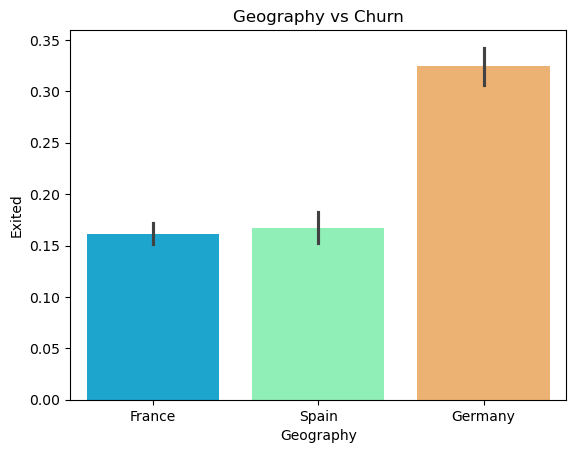

In [19]:
sns.barplot(x='Geography', y='Exited', data=df, hue='Geography', palette='rainbow')
plt.title('Geography vs Churn')
plt.show()

___________________________________
### Insight

*  👉 Germany has the highest churn rate compared to other countries.
* 👉 Geography is an important factor in customer churn.
___________________________________

___________________________________
## 4. Gender Analysis
❓ Question: Does gender affect churn rate?
___________________________________

In [20]:
pd.crosstab(df['Gender'], df['Exited'])

Exited,0,1
Gender,,
Female,3404,1139
Male,4559,898


In [21]:
df.groupby('Gender')['Exited'].mean().round(2)

Gender
Female    0.25
Male      0.16
Name: Exited, dtype: float64

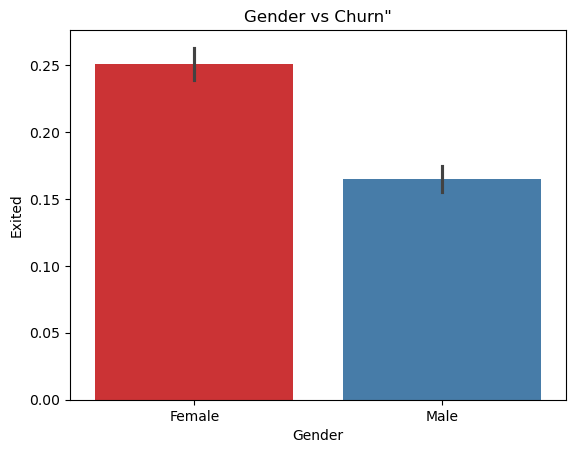

In [22]:
sns.barplot(x='Gender', y='Exited', data=df, hue='Gender', palette='Set1')
plt.title('Gender vs Churn"')
plt.show()

___________________________________
### Insight

* 👉 Female customers show slightly higher churn than male customers.
* 👉 Gender has moderate influence on churn behavior.
___________________________________

___________________________________
## 5. Age Analysis
❓ Question: How is age distributed in the dataset?
___________________________________

In [23]:
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

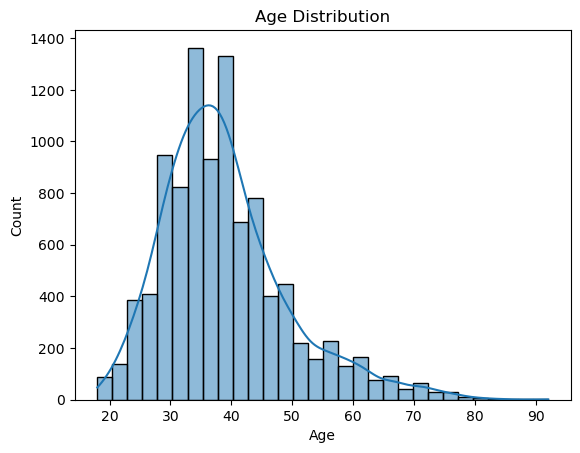

In [24]:
sns.histplot(x='Age', data=df, bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

___________________________________
## Insight

* 👉 Most customers are between 30–45 years old.
* 👉 Middle-aged customers form the major customer base.
___________________________________

___________________________________
## 6. Balance Analysis
❓ Question: Does balance affect churn?
___________________________________

In [25]:
df.groupby('Exited')['Balance'].mean().round(2)

Exited
0    72745.30
1    91108.54
Name: Balance, dtype: float64

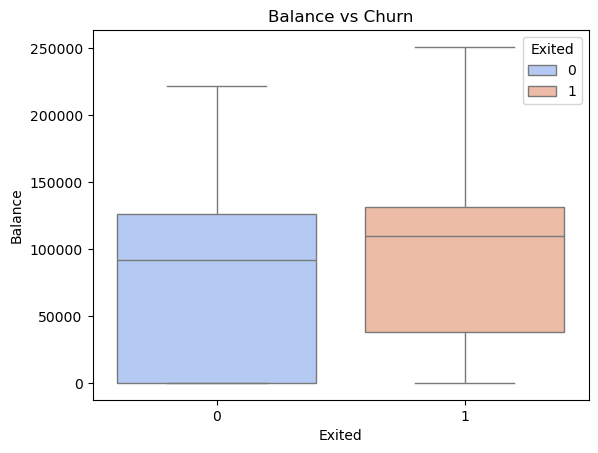

In [26]:
sns.boxplot(x='Exited', y='Balance', data=df, hue='Exited', palette='coolwarm')
plt.title('Balance vs Churn')
plt.show()

___________________________________
### Insight

* 👉 Customers with higher balance show slightly higher churn tendency.
* 👉 Balance alone is not a strong predictor but contributes to churn.
___________________________________

___________________________________
## 7. Credit Score Analysis
❓ Question: Does credit score affect churn behavior?
___________________________________

In [27]:
df.groupby('Exited')['CreditScore'].mean().round(2)

Exited
0    651.85
1    645.35
Name: CreditScore, dtype: float64

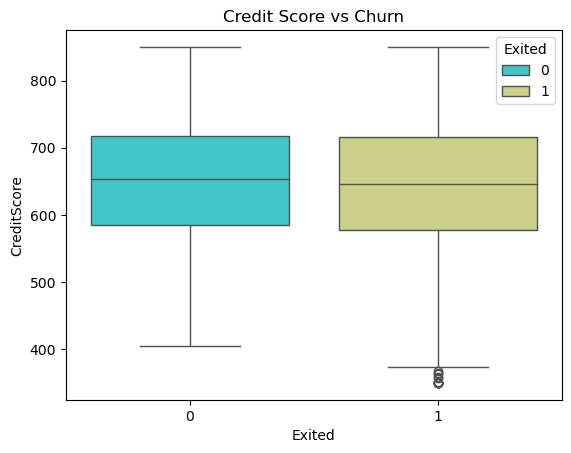

In [28]:
sns.boxplot(x='Exited', y='CreditScore', data =df, hue='Exited', palette='rainbow')
plt.title('Credit Score vs Churn')
plt.show()

___________________________________
### Insight

* 👉 Customers with lower credit scores are more likely to churn.
* 👉 Credit score is an important factor in prediction.
___________________________________

___________________________________ 
## SECTION 4  —  NumPy Statistical Analysis
* **Statistical Analysis**
    * Performing statistical analysis using NumPy to understand numerical feature distributions and data patterns.
___________________________________

___________________________________
### Average Customer Age
Calculating the average age of customers using NumPy.
___________________________________

In [29]:
round(np.mean(df['Age']),2)

np.float64(38.92)

___________________________________
### Median Account Balance
Calculating the median account balance using NumPy.
___________________________________

In [30]:
round(np.median(df['Balance']),2)

np.float64(97198.54)

___________________________________
### Maximum Account Balance
Finding the highest account balance in the dataset.
___________________________________

In [31]:
np.max(df['Balance'])

250898.09

___________________________________
### Minimum Credit Score
Finding the lowest credit score in the dataset.
___________________________________

In [32]:
np.min(df['CreditScore'])

350

___________________________________
### Salary Standard Deviation
Measuring the variation in customer salaries.
___________________________________

In [33]:
round(np.std(df['EstimatedSalary']),2)

57507.62

___________________________________
### Age Percentiles
Calculating the 25th, 50th, and 75th percentiles of customer age.
___________________________________

In [34]:
np.percentile(df['Age'], [25,50,75])

array([32., 37., 44.])

___________________________________
# SECTION 5 — Feature Engineering
* **Feature Engineering**
    * Creating meaningful business features like Age Group, Credit Category, and Balance Category to improve analysis and model performance.
___________________________________

In [35]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


___________________________________
## Age Group Creation
Categorizing customers based on age groups.
___________________________________

In [36]:
def age_group(age):
    if age < 30:
        return 'Young'
    elif age < 50:
        return 'Adult'
    else:
        return 'Senior'

df['Age_Group'] = df['Age'].apply(age_group)

In [37]:
# Check Results

df['Age_Group'].value_counts()

Age_Group
Adult     6964
Young     1641
Senior    1395
Name: count, dtype: int64

___________________________________
## Credit Score Category
Categorizing customers based on credit score quality.
___________________________________

In [38]:
def credit_category(score):
    if score < 500:
        return 'Poor'
    elif score < 700:
        return 'Average'
    else:
        return 'Good'

df['Credit_Category'] = df['CreditScore'].apply(credit_category)      

In [39]:
# Check Result

df['Credit_Category'].value_counts()

Credit_Category
Average    6220
Good       3148
Poor        632
Name: count, dtype: int64

___________________________________
## Balance Category
Categorizing customers based on account balance.
___________________________________

In [40]:
def balance_category(balance):
    if balance == 0:
        return 'Zero Balance'
    elif balance < 50000:
        return 'Low Balance'
    elif balance < 100000:
        return 'Medium Balance'
    else:
        return 'High Balance'

df['Balance_Category'] =  df['Balance'].apply(balance_category)

In [41]:
df['Balance_Category'].value_counts()

Balance_Category
High Balance      4799
Zero Balance      3617
Medium Balance    1509
Low Balance         75
Name: count, dtype: int64

___________________________________
### Verify New Features
Checking newly created columns.
___________________________________

In [42]:
df[['Age_Group', 'Credit_Category', 'Balance_Category']].head(10)

,Age_Group,Credit_Category,Balance_Category
0,Adult,Average,Zero Balance
1,Adult,Average,Medium Balance
2,Adult,Average,High Balance
3,Adult,Average,Zero Balance
4,Adult,Good,High Balance
5,Adult,Average,High Balance
6,Senior,Good,Zero Balance
7,Young,Poor,High Balance
8,Adult,Average,High Balance
9,Young,Average,High Balance


___________________________________
# 📌 SECTION 6 — Data Preprocessing
* **Data Preprocessing**
    * Preparing data for machine learning by encoding categorical variables and removing irrelevant columns.
___________________________________

In [43]:
# Check Dataset Columns

df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Age_Group',
       'Credit_Category', 'Balance_Category'],
      dtype='object')

___________________________________
## Drop Unnecessary Columns
* **Why?**
    * RowNumber → unique identifier
    * CustomerId → unique identifier
    * Surname → customer name

These are not useful for prediction
___________________________________

In [44]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [45]:
# Irrelevant columns removed to avoid model noise.

df.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Credit_Category,Balance_Category
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Average,Zero Balance
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,Average,Medium Balance
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Average,High Balance
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,Average,Zero Balance
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,Good,High Balance
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,Adult,Average,High Balance
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0,Senior,Good,Zero Balance
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,Young,Poor,High Balance
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,Adult,Average,High Balance
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,Young,Average,High Balance


In [46]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CreditScore       10000 non-null  int64  
 1   Geography         10000 non-null  object 
 2   Gender            10000 non-null  object 
 3   Age               10000 non-null  int64  
 4   Tenure            10000 non-null  int64  
 5   Balance           10000 non-null  float64
 6   NumOfProducts     10000 non-null  int64  
 7   HasCrCard         10000 non-null  int64  
 8   IsActiveMember    10000 non-null  int64  
 9   EstimatedSalary   10000 non-null  float64
 10  Exited            10000 non-null  int64  
 11  Age_Group         10000 non-null  object 
 12  Credit_Category   10000 non-null  object 
 13  Balance_Category  10000 non-null  object 
dtypes: float64(2), int64(7), object(5)
memory usage: 1.1+ MB


___________________________________
## Encode Categorical Variables
* Converting categorical columns into numerical format using one-hot encoding.
* Because machine learning models cannot understand text. Therefore it will have to be encoded.
___________________________________

In [47]:
df_encoded = pd.get_dummies(
    df, columns=[
            'Geography',
            'Gender',
            'Age_Group',
            'Credit_Category',
            'Balance_Category'],

    drop_first=True,
    dtype=int)

In [48]:
# Displaying dataset after categorical encoding.

df_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,Age_Group_Senior,Age_Group_Young,Credit_Category_Good,Credit_Category_Poor,Balance_Category_Low Balance,Balance_Category_Medium Balance,Balance_Category_Zero Balance
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0,0,0,0,0,0,0,1
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0,0,0,0,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0,0,0,0,0,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0,0,0,0,0,0,0,1
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0,0,0,1,0,0,0,0


In [49]:
# Dataset Shape

df_encoded.shape

(10000, 19)

In [50]:
# Dataset Information

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   CreditScore                      10000 non-null  int64  
 1   Age                              10000 non-null  int64  
 2   Tenure                           10000 non-null  int64  
 3   Balance                          10000 non-null  float64
 4   NumOfProducts                    10000 non-null  int64  
 5   HasCrCard                        10000 non-null  int64  
 6   IsActiveMember                   10000 non-null  int64  
 7   EstimatedSalary                  10000 non-null  float64
 8   Exited                           10000 non-null  int64  
 9   Geography_Germany                10000 non-null  int64  
 10  Geography_Spain                  10000 non-null  int64  
 11  Gender_Male                      10000 non-null  int64  
 12  Age_Group_Senior   

___________________________________
# SECTION 7 — Machine Learning Model
 
* ### Train-Test Split
    * Splitting dataset into training and testing sets to evaluate model performance effectively.
___________________________________

___________________________________
## Feature and Target Variables Split
Separating independent variables and target variable.
___________________________________

In [51]:
x = df_encoded.drop('Exited', axis=1)

y  = df_encoded['Exited']

In [52]:
# Checking feature variables and target variable.

x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Age_Group_Senior,Age_Group_Young,Credit_Category_Good,Credit_Category_Poor,Balance_Category_Low Balance,Balance_Category_Medium Balance,Balance_Category_Zero Balance
0,619,42,2,0.00,1,1,1,101348.88,0,0,0,0,0,0,0,0,0,1
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0,0,0,0,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0,0,0,0,0,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0,0,0,0,0,0,1
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0,0,0,1,0,0,0,0


In [53]:
# Checking feature variables and target variable.

y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

___________________________________
## Train Test Split
Splitting the dataset into training and testing sets.
___________________________________

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

___________________________________
## Training and Testing Data Shapes
Checking the dimensions of training and testing datasets.
___________________________________

In [56]:
x_train.shape

(8000, 18)

In [57]:
x_test.shape

(2000, 18)

In [58]:
y_train.shape

(8000,)

In [59]:
y_test.shape

(2000,)

___________________________________
## Standardize the Variables
* **Standardize the Variables means:-**  Bringing every feature on the same scale. So that the model does not get confused by small and big numbers.
* Standardizing variables = converting each feature into a single scale (mean = 0, std = 1)
___________________________________

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

___________________________________
## SECTION 8 — LOGISTIC REGRESSION Model
* Training a Logistic Regression model to predict customer churn.
___________________________________

In [61]:
# Import Logistic Regression Model

from sklearn.linear_model import LogisticRegression

In [62]:
# Creating the Logistic Regression model object.

model_lr = LogisticRegression(max_iter=1000)

In [63]:
# Training the Logistic Regression model using training data.

model_lr.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

___________________________________
## Make Customer Churn Prediction
Predicting churn using the trained model.
___________________________________

In [64]:
# Prediction

y_pred_lr = model_lr.predict(x_test_scaled)

In [65]:
y_pred_lr[:5]

array([0, 0, 0, 1, 0])

___________________________________
## Model Evaluation
* **Model Evaluation**
    * Evaluating the performance of the Logistic Regression model.
___________________________________

### Model Accuracy
* Evaluating the overall prediction accuracy of the Logistic Regression model.
___________________________________

In [66]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_lr)

0.816

___________________________________
### Confusion Matrix
Analyzing correct and incorrect churn predictions.
___________________________________

In [67]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_lr)

array([[1546,   61],
       [ 307,   86]])

___________________________________
### Classification Report
Generating detailed classification metrics for model evaluation.
___________________________________

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.59      0.22      0.32       393

    accuracy                           0.82      2000
   macro avg       0.71      0.59      0.61      2000
weighted avg       0.79      0.82      0.78      2000



___________________________________
#### Logistic Regression MINI INSIGHT 
* ✔ Fast baseline model
* ✔ Good at overall accuracy (81%)
* ❌ Poor recall for churn customers (0.22)
* ❌ Missed many important churn cases (high FN)
___________________________________

___________________________________
## SECTION 9 — Decision Tree Classifier
* Training a Decision Tree model to capture non-linear relationships in churn data.
___________________________________

In [69]:
# Import & Train Model

from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [70]:
# Prediction

y_pred_dt = model_dt.predict(x_test)

In [71]:
y_pred_dt[:5]

array([1, 0, 0, 0, 0])

In [72]:
# Accuracy

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_dt)

0.7815

In [73]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_dt)

array([[1368,  239],
       [ 198,  195]])

In [74]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1607
           1       0.45      0.50      0.47       393

    accuracy                           0.78      2000
   macro avg       0.66      0.67      0.67      2000
weighted avg       0.79      0.78      0.79      2000



___________________________________
#### Decision Tree MINI INSIGHT 
* ✔ Better than Logistic Regression  
* ✔ Captures non-linear patterns  
* ✔ Churn recall improved (0.50)  
* ❌ Overfitting risk  
* ❌ Moderate false positives
___________________________________

___________________________________
## SECTION 10 — Random Forest Classifier
Building a Random Forest model using multiple decision trees to improve accuracy and reduce overfitting.
___________________________________

In [75]:
# Import & Train Model

from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

model_rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [76]:
# Prediction

y_pred_rf = model_rf.predict(x_test)

In [77]:
y_pred_rf[:5]

array([0, 0, 0, 0, 0])

In [78]:
# Accuracy

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_rf)

0.869

In [79]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_rf)

array([[1550,   57],
       [ 205,  188]])

In [80]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.77      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



___________________________________
#### Random Forest MINI INSIGHT 
✔ Best overall performance (86.9%)  
✔ Balanced precision and recall  
✔ Low false positives  
✔ Best churn detection among all models  
❌ Still some churn cases missed (FN exists)
___________________________________

___________________________________
# 11 — Model Comparison
Comparing the performance of Logistic Regression, Decision Tree, and Random Forest models to identify the best model for customer churn prediction.
___________________________________

In [81]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.816, 0.7815, 0.869],
    'Precision': [0.59, 0.45, 0.77],
    'Recall': [0.22, 0.50, 0.48],
    'F1 Score': [0.32, 0.47, 0.59]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8160,0.59,0.22,0.32
1,Decision Tree,0.7815,0.45,0.50,0.47
2,Random Forest,0.8690,0.77,0.48,0.59


___________________________________
## Model Comparison Visualization

Visualizing model accuracy to compare performance across different algorithms.
___________________________________

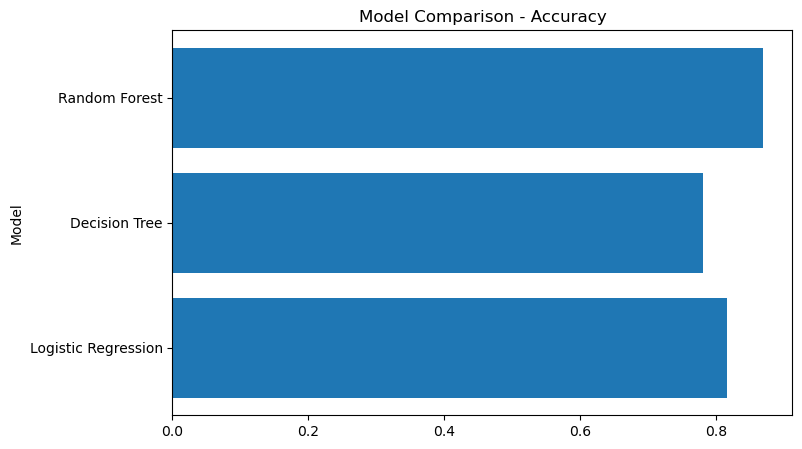

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(comparison_df['Model'], comparison_df['Accuracy'])

plt.title('Model Comparison - Accuracy')
plt.ylabel('Model')

plt.show()

___________________________________
### Best Model Selection
* **Best Model: Random Forest** 
    * **Reason**
        * Highest Accuracy
        * Highest Precision
        * Highest F1-Score
        * Better overall performance
___________________________________

___________________________________
## Insights
* Random Forest achieved the highest accuracy (86.9%).
* Logistic Regression showed good overall accuracy but struggled to identify churned customers.
* Decision Tree detected more churned customers than Logistic Regression but produced lower overall accuracy.
* Random Forest provided the best balance between churn detection and overall prediction performance.
* Random Forest was selected as the final model for customer churn prediction.
___________________________________

___________________________________
# SECTION 12 — Model Interpretation
Understanding which features influence customer churn predictions and interpreting model behavior.
___________________________________

___________________________________
## Logistic Regression Coefficients

Analyzing feature coefficients to understand how different variables impact churn prediction.
___________________________________

In [83]:
model_lr

LogisticRegression(max_iter=1000)

In [84]:
x_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Age_Group_Senior,Age_Group_Young,Credit_Category_Good,Credit_Category_Poor,Balance_Category_Low Balance,Balance_Category_Medium Balance,Balance_Category_Zero Balance
9254,686,32,6,0.00,2,1,1,179093.26,0,0,1,0,0,0,0,0,0,1
1561,632,42,4,119624.60,2,1,1,195978.86,1,0,1,0,0,0,0,0,0,0
1670,559,24,3,114739.92,1,1,0,85891.02,0,1,1,0,1,0,0,0,0,0
6087,561,27,9,135637.00,1,1,0,153080.40,0,0,0,0,1,0,0,0,0,0
6669,517,56,9,142147.32,1,0,0,39488.04,0,0,1,1,0,0,0,0,0,0


In [85]:
# Create Coefficient Table

coef_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model_lr.coef_[0]
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False)

,Feature,Coefficient
1,Age,0.536898
8,Geography_Germany,0.332126
11,Age_Group_Senior,0.193997
13,Credit_Category_Good,0.118701
15,Balance_Category_Low Balance,0.043702
9,Geography_Spain,0.043550
7,EstimatedSalary,0.019533
5,HasCrCard,-0.007699
3,Balance,-0.030642
2,Tenure,-0.039415


___________________________________
## Visualization
Visualizing Logistic Regression coefficients to identify important factors affecting churn.
___________________________________

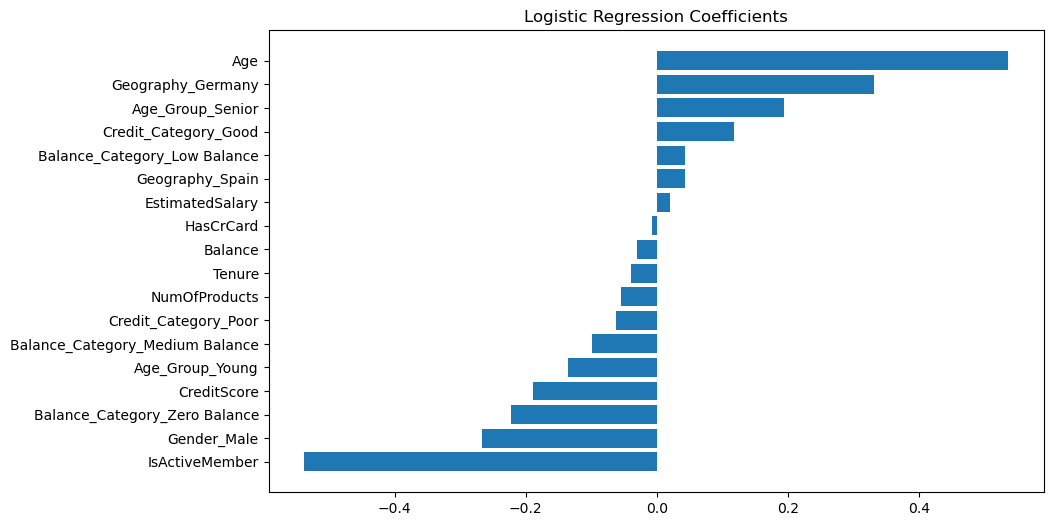

In [86]:
coef_df= coef_df.sort_values(by = 'Coefficient')

plt.figure(figsize=(10,6))

plt.barh(
    coef_df['Feature'],
    coef_df['Coefficient'])

plt.title('Logistic Regression Coefficients')
plt.show()

___________________________________
## Random Forest Feature Importance
Identifying the most influential features used by the Random Forest model.
___________________________________

In [87]:
model_rf

RandomForestClassifier(random_state=42)

In [88]:
# Feature Importance Table

importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': model_rf.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False)

,Feature,Importance
1,Age,0.193370
7,EstimatedSalary,0.136947
0,CreditScore,0.129436
4,NumOfProducts,0.126794
3,Balance,0.116727
2,Tenure,0.081416
6,IsActiveMember,0.050353
11,Age_Group_Senior,0.033131
8,Geography_Germany,0.024908
10,Gender_Male,0.020360


___________________________________
### Feature Importance Visualization
Visualizing feature importance scores from the Random Forest model.
___________________________________

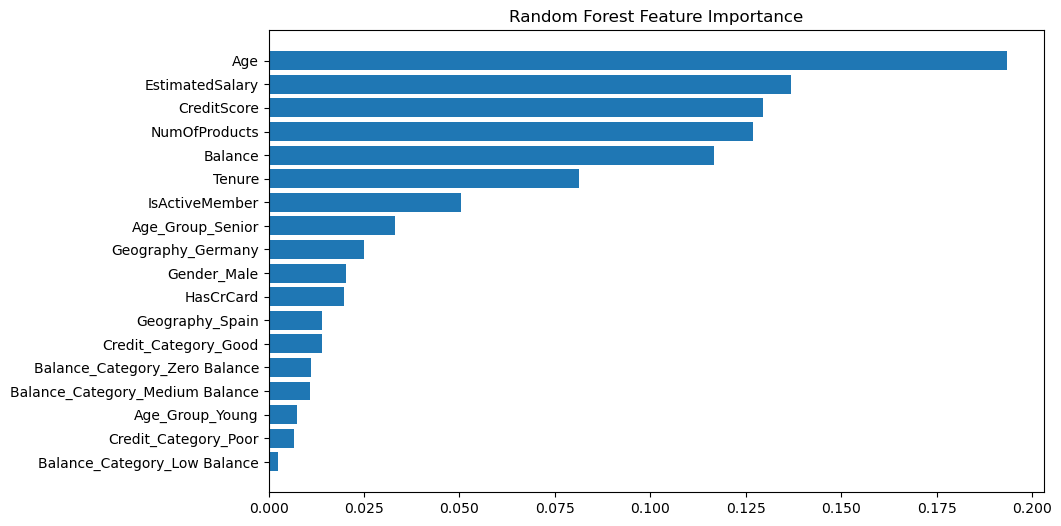

In [89]:
importance_df = importance_df.sort_values(by='Importance')

plt.figure(figsize=(10,6))

plt.barh(importance_df['Feature'],
        importance_df['Importance'])

plt.title('Random Forest Feature Importance')
plt.show()

___________________________________
### Insight
Age was identified as the most important factor affecting customer churn. Customer activity, credit score, balance, salary, and product usage also influenced churn behavior. The results indicate that older and inactive customers have a higher likelihood of leaving the bank.
___________________________________

___________________________________
# Section 13 — K-Means Clustering
Applying K-Means Clustering to segment customers into different groups based on their characteristics and behavior.
___________________________________

In [90]:
# Import Libraries

from sklearn.cluster import KMeans

___________________________________
## Select Features
Selecting important numerical features for clustering customers based on behavior and financial profile.
___________________________________

In [91]:
cluster_data = df[['CreditScore', 'Age', 'Balance', 'EstimatedSalary']]

___________________________________
## Feature Scaling
* **Feature Scaling for Clustering**
    * Standardizing numerical features before applying K-Means clustering.
___________________________________

In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

___________________________________
## Elbow Method (WCSS Calculation)
Finding optimal number of clusters using Within Cluster Sum of Squares (WCSS).
___________________________________

In [93]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10)

    kmeans.fit(cluster_scaled)

    wcss.append(kmeans.inertia_)

___________________________________
## Elbow Chart
Visualizing WCSS to identify best value of **K for K-Means clustering.**
___________________________________

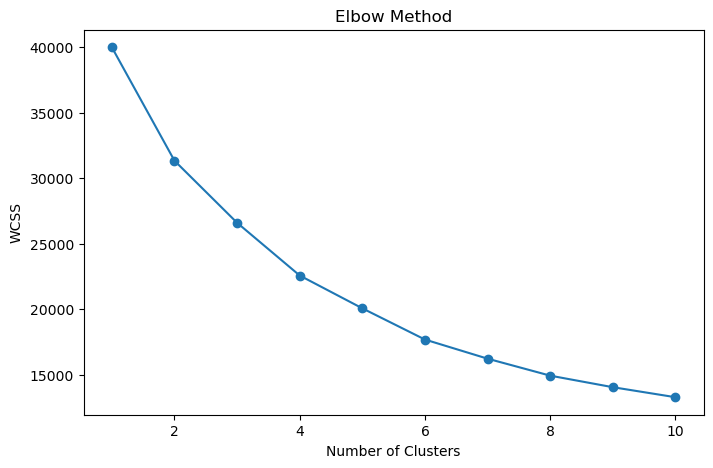

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

___________________________________
## Final KMeans Model
Applying K-Means clustering algorithm to segment customers into 4 distinct groups based on financial and behavioral attributes.
___________________________________

In [95]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(cluster_scaled)

In [96]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Credit_Category,Balance_Category,Cluster
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Average,Zero Balance,2
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,Average,Medium Balance,3
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Average,High Balance,3
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,Average,Zero Balance,2
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,Good,High Balance,0


In [97]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Credit_Category,Balance_Category,Cluster
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Average,Zero Balance,2
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,Average,Medium Balance,3
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Average,High Balance,3
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,Average,Zero Balance,2
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,Good,High Balance,0


___________________________________
## Cluster Distribution Analysis
Analyzing how customers are distributed across different clusters.
___________________________________

In [98]:
df['Cluster'].value_counts()

Cluster
2    3325
3    2732
0    2676
1    1267
Name: count, dtype: int64

___________________________________
## Cluster Visualization
Visualizing customer clusters using two main features.
___________________________________

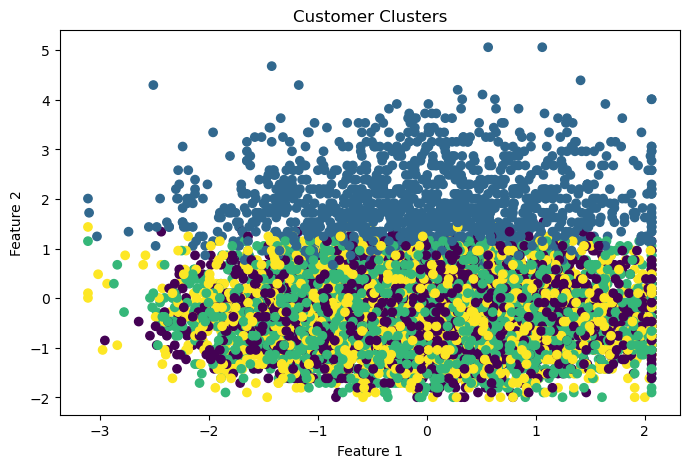

In [99]:
plt.figure(figsize=(8,5))

plt.scatter(
    cluster_scaled[:,0],
    cluster_scaled[:,1],
    c=df['Cluster'],
    cmap='viridis')

plt.title('Customer Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.show()

___________________________________
## Cluster Profiling
Understanding characteristics of each customer segment created by K-Means.
___________________________________

In [100]:
df.groupby('Cluster').mean(numeric_only=True)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
Cluster,,,,,,,,,
0,655.072870,36.121824,4.966741,122008.383655,1.373318,0.704783,0.494395,49707.232672,0.196188
1,649.018942,59.292818,4.948698,80640.615533,1.471192,0.691397,0.657459,96722.190118,0.438832
2,648.401203,35.742256,5.086316,1390.845759,1.782857,0.715489,0.490827,99385.665669,0.118195
3,649.367496,36.086750,4.998170,121364.654535,1.403734,0.700586,0.498902,151859.989367,0.206076


___________________________________
### Insights
* Cluster 1 has the highest churn rate (43.88%) and represents the most vulnerable customer segment.
* Cluster 2 contains the largest number of customers with the lowest churn rate (11.82%).
* Clusters 0 and 3 represent high-balance customers and contribute significant business value.
* Premium customers (Cluster 3) have the highest average salary.
* Senior customers appear more likely to leave the bank than younger customers.
___________________________________

### K-Means Conclusion

K-Means clustering successfully segmented customers into four distinct groups. Cluster 1 emerged as the highest-risk customer segment due to its significantly higher churn rate, while Cluster 2 represented a stable low-risk customer group. The clustering analysis helps identify customer segments that require different retention and engagement strategies.

___________________________________
# SECTION 14 — Business Insights

Summarizing key findings and recommendations derived from the customer churn analysis project.
___________________________________

___________________________________
## Business Insights

* Germany recorded the highest customer churn rate.
* Senior customers were more likely to churn.
* Inactive customers showed significantly higher churn behavior.
* Customers with poor credit profiles were more likely to leave the bank.
* Account balance and product usage influenced customer retention.
* K-Means clustering identified a high-risk customer segment.
* Age was the most influential factor in churn prediction.
* Random Forest achieved the best predictive performance.
___________________________________

___________________________________
## Business Recommendations

* Focus retention campaigns on senior and inactive customers.
* Improve engagement strategies for high-risk customer segments.
* Strengthen customer retention efforts in high-churn regions.
* Offer personalized products and services.
* Use the Random Forest model for proactive churn prediction.
___________________________________

___________________________________
# SECTION 15 — Final Conclusion

Summarizing the overall findings, machine learning performance, and business value of the customer churn prediction project.
___________________________________

___________________________________
## Final Conclusion

* This project analyzed customer churn behavior using data analysis, feature engineering, customer segmentation, and machine learning techniques.
* The analysis revealed that customer age, activity status, credit score, account balance, salary, and product usage significantly influence churn behavior.
* K-Means clustering successfully segmented customers into different groups and identified a high-risk customer segment with a higher tendency to churn.
* Three machine learning models were evaluated: Logistic Regression, Decision Tree, and Random Forest. Among them, Random Forest achieved the best performance with an accuracy of 86.9%, making it the most effective model for customer churn prediction.
* The project demonstrates how machine learning can help banks identify high-risk customers early and support proactive retention strategies to reduce customer churn.
___________________________________

___________________________________
## Final Project Outcome
* Successfully analyzed customer churn patterns.
* Built and evaluated multiple machine learning models.
* Performed customer segmentation using K-Means clustering.
* Identified key factors driving customer churn.
* Selected Random Forest as the best-performing model.
* Generated actionable business recommendations.
___________________________________

___________________________________
## Final Insight
Customer churn is influenced by a combination of demographic, financial, and behavioral factors. By leveraging customer segmentation and machine learning models, organizations can proactively identify customers at risk of leaving and implement targeted retention strategies.
___________________________________